In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn import tree

In [2]:
iris = pd.read_csv("../data/flores_iris.csv")
iris = iris.sample(frac=1) # Embaralhando o dataset
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
100,101,6.3,3.3,6.0,2.5,Iris-virginica
75,76,6.6,3.0,4.4,1.4,Iris-versicolor
94,95,5.6,2.7,4.2,1.3,Iris-versicolor
146,147,6.3,2.5,5.0,1.9,Iris-virginica
102,103,7.1,3.0,5.9,2.1,Iris-virginica
...,...,...,...,...,...,...
62,63,6.0,2.2,4.0,1.0,Iris-versicolor
115,116,6.4,3.2,5.3,2.3,Iris-virginica
78,79,6.0,2.9,4.5,1.5,Iris-versicolor
43,44,5.0,3.5,1.6,0.6,Iris-setosa


In [3]:
'''
Separando X (features) e y (classes)
'''

X = iris.drop(['Species', 'Id'], axis=1)
y = iris['Species']

In [4]:
'''
Faremos uma classificação binária: 1 é Iris-setosa e 0 não
'''

y = y.map(
    {'Iris-setosa': 0,
     'Iris-versicolor': 1,
     'Iris-virginica': 0
     })

In [5]:
'''
Divisão entre conjunto de treinamento e validação
'''

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
arvore_decisao = tree.DecisionTreeClassifier()

In [10]:
model = arvore_decisao.fit(X_train, y_train)

In [13]:
respostas_modelo = model.predict(X_val)

In [14]:
'''
No classification report: Precisão -> TP/(TP+FP), Sensibilidade -> Recall TP/(TP+FN)
'''
print(classification_report(y_val, respostas_modelo))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92        18
           1       0.91      0.83      0.87        12

    accuracy                           0.90        30
   macro avg       0.90      0.89      0.89        30
weighted avg       0.90      0.90      0.90        30



'Species'

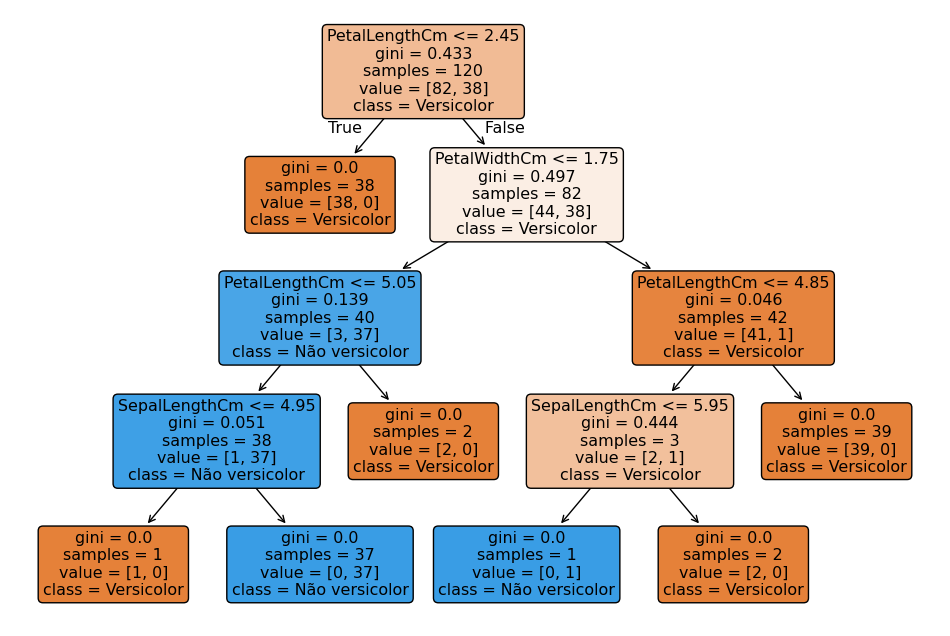

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))  
tree.plot_tree(model, 
               feature_names=iris.columns[1:5],
               class_names=["Versicolor", "Não versicolor"],
               filled=True,
               rounded=True)
plt.show()